<a href="https://colab.research.google.com/github/EdgarPrueba/Portafolio1/blob/main/NB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portafolio II — Predicción de MCS mediante aprendizaje automático

En este laboratorio se estudia la predicción del **Modulation and Coding Scheme (MCS)** de señales sintéticas basadas en el estándar IEEE 802.11 a partir de sus muestras en fase y cuadratura (I/Q).

El MCS representa una combinación de parámetros de transmisión, incluyendo la modulación y la tasa de codificación. Debido a que el ruido y las condiciones del canal afectan la señal recibida, el nivel de **SNR (Signal-to-Noise Ratio)** puede influir en la capacidad de un modelo para identificar correctamente el MCS.

Se compararán dos clasificadores:

* **Regresión Logística multinomial**, como línea base clásica.
* **Perceptrón Multicapa (MLP)** implementado en PyTorch.

El objetivo principal es analizar cómo varía el desempeño de ambos modelos con el nivel de SNR.

$$
\text{Señal I/Q} \rightarrow \text{características} \rightarrow \text{clasificador} \rightarrow \text{MCS}
$$

> **Nota:** el conjunto de datos utilizado es sintético y está basado en IEEE 802.11; no corresponde a mediciones reales obtenidas de una red Wi-Fi.




---
## 1. Configuración y carga del conjunto de datos

Se establece una semilla aleatoria para favorecer la reproducibilidad y se selecciona automáticamente el dispositivo de procesamiento disponible.

El conjunto de datos sintético basado en IEEE 802.11 se descarga y se inspecciona para identificar su estructura, dimensiones, representación de las señales I/Q y variables asociadas.

Se presta especial atención a las etiquetas MCS y a los niveles de SNR, ya que serán fundamentales para el entrenamiento de los clasificadores y el análisis de su desempeño bajo diferentes condiciones de recepción.




In [ ]:
# ==========================================
# CELDA 1: Setup, Descarga e Inspección
# ==========================================

import os
import requests
import numpy as np
import torch

# ------------------------------------------
# 1. Configuración reproducible
# ------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Semilla: {SEED}")
print(f"Dispositivo: {device}")


# ------------------------------------------
# 2. Descarga del dataset
# ------------------------------------------

url_dataset = "https://media.githubusercontent.com/media/RalucaNelega/IEEE-802.11-signal-dataset/main/dataset.npy"
url_columns = "https://raw.githubusercontent.com/RalucaNelega/IEEE-802.11-signal-dataset/main/columns.txt"

def download_file(url, filename):
    if not os.path.exists(filename) or os.path.getsize(filename) == 0:
        print(f"Descargando {filename}...")

        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(filename, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

        print(f"{filename} descargado correctamente.")
    else:
        print(f"{filename} ya existe.")

download_file(url_columns, "columns.txt")
download_file(url_dataset, "dataset.npy")


# ------------------------------------------
# 3. Carga del dataset
# ------------------------------------------

data = np.load("dataset.npy", allow_pickle=True)

print("\n--- INFORMACIÓN GENERAL ---")
print(f"Tipo: {type(data)}")
print(f"Shape: {data.shape}")
print(f"Dimensiones: {data.ndim}")
print(f"dtype: {data.dtype}")
print(f"Tamaño: {os.path.getsize('dataset.npy') / 1024**2:.2f} MB")


# ------------------------------------------
# 4. Identificación de variables
# ------------------------------------------

with open("columns.txt", "r") as f:
    columns = [line.strip() for line in f.readlines()]

print("\n--- VARIABLES DISPONIBLES ---")
print(columns)


# ------------------------------------------
# 5. Inspección del primer registro
# ------------------------------------------

print("\n--- PRIMER REGISTRO ---")

sample = data[0]

for name in data.dtype.names:
    value = sample[name]

    print(f"\n{name}:")

    if isinstance(value, np.ndarray):
        print(f"Shape: {value.shape}")
        print(f"dtype: {value.dtype}")
        print(f"Primeros valores: {value.flatten()[:10]}")
    else:
        print(value)


# ------------------------------------------
# 6. Distribución de MCS
# ------------------------------------------

print("\n--- DISTRIBUCIÓN DE MCS ---")

mcs_values, mcs_counts = np.unique(
    data["MCS"],
    return_counts=True
)

for value, count in zip(mcs_values, mcs_counts):
    print(f"MCS {value}: {count} muestras")


# ------------------------------------------
# 7. Rango de SNR
# ------------------------------------------

print("\n--- INFORMACIÓN DE SNR ---")

snr_values = data["SNR"]

print(f"SNR mínimo: {snr_values.min():.2f} dB")
print(f"SNR máximo: {snr_values.max():.2f} dB")
print(f"Valores únicos de SNR: {len(np.unique(snr_values))}")


# ------------------------------------------
# 8. Condiciones del dataset
# ------------------------------------------

print("\n--- DELAY PROFILE ---")

profiles, profile_counts = np.unique(
    data["DelayProfile"],
    return_counts=True
)

for profile, count in zip(profiles, profile_counts):
    print(f"{profile}: {count} muestras")


print("\n--- IEEE STANDARD ---")
print(np.unique(data["IEEE Standard"]))

print("\n--- IEEE TRANSMISSION ---")
print(np.unique(data["IEEE Transmission"]))

Semilla: 42
Dispositivo: cpu
columns.txt ya existe.
dataset.npy ya existe.

--- INFORMACIÓN GENERAL ---
Tipo: <class 'numpy.rec.recarray'>
Shape: (134400,)
Dimensiones: 1
dtype: (numpy.record, [('IQSamples', 'O'), ('DelayProfile', 'O'), ('MCS', 'O'), ('SNR', 'O'), ('Modulation', 'O'), ('Speed', 'O'), ('IEEE Standard', 'O'), ('IEEE Transmission', 'O')])
Tamaño: 1064.80 MB

--- VARIABLES DISPONIBLES ---
['IQSamples', 'DelayProfile', 'MCS', 'SNR', 'Modulation', 'Speed', 'IEEE Standard', 'IEEE Transmission']

--- PRIMER REGISTRO ---

IQSamples:
Shape: (512,)
dtype: complex128
Primeros valores: [-1.00426357-1.02994922j  1.23316537-0.24255547j  0.05724138-0.42602645j
 -0.68713995-0.23423773j  0.75006264-0.43711072j  0.78434157-0.33925065j
  0.53354614+0.61609817j -0.63574552+0.11828052j  0.78476787-0.43939847j
  0.82736028+2.302372j  ]

DelayProfile:
Ideal     

MCS:
0.0

SNR:
9.38

Modulation:
OFDM

Speed:
120

IEEE Standard:
802.11 n

IEEE Transmission:
OFDM HT 40MHz

--- DISTRIBUCIÓN DE M

## 2. Preprocesamiento y definición de modelos

Cada señal contiene 512 muestras complejas:

$$
x[n] = I[n] + jQ[n]
$$

Para utilizar estas señales como entrada de los clasificadores, se separan sus componentes en fase y cuadratura y se construye un vector de 1024 características:

$$
X=[I_1,\ldots,I_{512},Q_1,\ldots,Q_{512}]
$$

La variable objetivo es el **MCS**, que contiene ocho clases (MCS 0–7).

Los datos se dividen en conjuntos de entrenamiento y prueba de forma estratificada según el MCS. La normalización de las características se calcula únicamente a partir del conjunto de entrenamiento para evitar fuga de información.

Se comparan dos modelos:

1. **Regresión Logística multinomial**, utilizada como línea base.
2. **MLP**, implementado en PyTorch, con dos capas ocultas y activaciones ReLU.

$$
1024 \rightarrow 128 \rightarrow 64 \rightarrow 8
$$

Ambos modelos reciben únicamente las características I/Q. El SNR se conserva como variable de análisis para estudiar posteriormente su relación con la precisión de la predicción.


In [ ]:
# ==========================================
# CELDA 2: Preprocesamiento y Modelos
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from torch import nn

# ------------------------------------------
# 1. Construcción de X a partir de I/Q
# ------------------------------------------

iq = np.stack(data["IQSamples"])

X = np.hstack([
    iq.real,
    iq.imag
])

y = data["MCS"].astype(int)
snr = data["SNR"].astype(float)

print("--- DATOS PREPARADOS ---")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"Número de clases MCS: {len(np.unique(y))}")

# ------------------------------------------
# 2. División entrenamiento / prueba
# ------------------------------------------

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X,
    y,
    snr,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\n--- DIVISIÓN DE DATOS ---")
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

# ------------------------------------------
# 3. Normalización
# ------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------
# 4. Línea base: Regresión Logística
# ------------------------------------------

logistic_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

# ------------------------------------------
# 5. MLP en PyTorch
# ------------------------------------------

class MLP(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train.shape[1]
num_classes = len(np.unique(y))

mlp_model = MLP(
    input_size=input_size,
    num_classes=num_classes
).to(device)

print("\n--- MODELOS ---")
print(f"Regresión Logística: {input_size} características → {num_classes} clases")
print(f"MLP: {input_size} → 128 → 64 → {num_classes}")

print(
    f"Parámetros MLP: "
    f"{sum(p.numel() for p in mlp_model.parameters()):,}"
)

--- DATOS PREPARADOS ---
X: (134400, 1024)
y: (134400,)
Número de clases MCS: 8

--- DIVISIÓN DE DATOS ---
Entrenamiento: 107520 muestras
Prueba:        26880 muestras

--- MODELOS ---
Regresión Logística: 1024 características → 8 clases
MLP: 1024 → 128 → 64 → 8
Parámetros MLP: 139,976


## 3. Entrenamiento y evaluación

Se entrenan los dos clasificadores utilizando las muestras I/Q del conjunto de entrenamiento.

La Regresión Logística se utiliza como línea base clásica, mientras que el MLP utiliza una función de pérdida **Cross-Entropy** y el optimizador Adam.

El desempeño se evalúa mediante la exactitud (*Accuracy*) sobre el conjunto de prueba:

$$
Accuracy =
\frac{\text{número de predicciones correctas}}
{\text{número total de muestras}}
$$

En esta etapa se obtiene el desempeño global de cada modelo. Posteriormente, la evaluación se separará por niveles de SNR para estudiar el efecto de las condiciones de recepción sobre la predicción del MCS.


In [ ]:
# ==========================================
# CELDA 3: Entrenamiento y Evaluación
# ==========================================

import time
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------
# 1. Entrenamiento de Regresión Logística
# ------------------------------------------

print("--- REGRESIÓN LOGÍSTICA ---")

start_time = time.time()

logistic_model.fit(X_train, y_train)

logistic_time = time.time() - start_time

logistic_pred = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"Tiempo de entrenamiento: {logistic_time:.2f} s")

# ------------------------------------------
# 2. Preparación de datos para PyTorch
# ------------------------------------------

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

# ------------------------------------------
# 3. Entrenamiento del MLP
# ------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-3
)

epochs = 20

print("\n--- MLP ---")

start_time = time.time()

for epoch in range(epochs):

    mlp_model.train()

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = mlp_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

mlp_time = time.time() - start_time

# ------------------------------------------
# 4. Evaluación del MLP
# ------------------------------------------

mlp_model.eval()

with torch.no_grad():

    outputs = mlp_model(
        X_test_tensor.to(device)
    )

    mlp_pred = torch.argmax(
        outputs,
        dim=1
    ).cpu().numpy()

mlp_accuracy = accuracy_score(
    y_test,
    mlp_pred
)

print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Tiempo de entrenamiento: {mlp_time:.2f} s")

# ------------------------------------------
# 5. Comparación
# ------------------------------------------

print("\n--- COMPARACIÓN FINAL ---")

print(f"Regresión Logística: {logistic_accuracy:.4f}")
print(f"MLP:                 {mlp_accuracy:.4f}")

--- REGRESIÓN LOGÍSTICA ---
Accuracy: 0.1798
Tiempo de entrenamiento: 25.75 s

--- MLP ---
Accuracy: 0.4498
Tiempo de entrenamiento: 75.61 s

--- COMPARACIÓN FINAL ---
Regresión Logística: 0.1798
MLP:                 0.4498


## 4. Efecto del SNR

Para estudiar la influencia de las condiciones de recepción sobre la predicción del MCS, se evalúa la exactitud de ambos modelos para diferentes rangos de SNR.

Debido a que el dataset contiene numerosos valores decimales de SNR, estos se agrupan en intervalos de 5 dB. Para cada intervalo se calcula la exactitud de las predicciones realizadas sobre el conjunto de prueba.

El análisis permite estudiar la relación:

$$
Accuracy=f(SNR)
$$

La hipótesis es que una mayor relación señal-ruido puede facilitar la identificación del MCS al proporcionar muestras I/Q menos afectadas por el ruido. Sin embargo, la tendencia final se determinará a partir de los resultados experimentales.


SNR 3–8 dB | N =  2808 | Logística = 0.2457 | MLP = 0.4751
SNR 8–13 dB | N =  5881 | Logística = 0.1988 | MLP = 0.4515
SNR 13–18 dB | N =  6476 | Logística = 0.1867 | MLP = 0.4490
SNR 18–23 dB | N =  5678 | Logística = 0.1740 | MLP = 0.4523
SNR 23–28 dB | N =  3727 | Logística = 0.1511 | MLP = 0.4352
SNR 28–35 dB | N =  2310 | Logística = 0.0922 | MLP = 0.4342


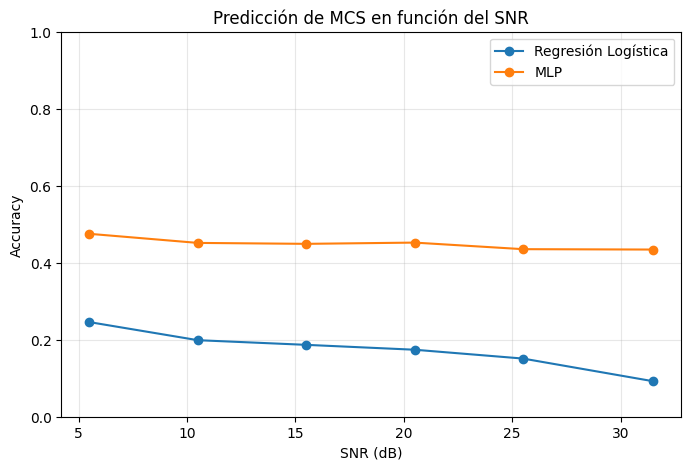

In [ ]:
# ==========================================
# CELDA 4: Accuracy vs SNR
# ==========================================

import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Definir intervalos de SNR
# ------------------------------------------

snr_bins = np.array([3, 8, 13, 18, 23, 28, 35])
snr_labels = [
    "3–<8",
    "8–<13",
    "13–<18",
    "18–<23",
    "23–<28",
    "28–35"
]

snr_accuracy_logistic = []
snr_accuracy_mlp = []
snr_centers = []

# ------------------------------------------
# 2. Evaluación por intervalo
# ------------------------------------------

for i in range(len(snr_bins) - 1):

    lower = snr_bins[i]
    upper = snr_bins[i + 1]

    if i == len(snr_bins) - 2:
        mask = (snr_test >= lower) & (snr_test <= upper)
    else:
        mask = (snr_test >= lower) & (snr_test < upper)

    if np.sum(mask) == 0:
        continue

    logistic_acc = accuracy_score(
        y_test[mask],
        logistic_pred[mask]
    )

    mlp_acc = accuracy_score(
        y_test[mask],
        mlp_pred[mask]
    )

    snr_accuracy_logistic.append(logistic_acc)
    snr_accuracy_mlp.append(mlp_acc)
    snr_centers.append((lower + upper) / 2)

    print(
        f"SNR {lower}–{upper} dB | "
        f"N = {np.sum(mask):5d} | "
        f"Logística = {logistic_acc:.4f} | "
        f"MLP = {mlp_acc:.4f}"
    )

# ------------------------------------------
# 3. Gráfica principal
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    snr_centers,
    snr_accuracy_logistic,
    marker="o",
    label="Regresión Logística"
)

plt.plot(
    snr_centers,
    snr_accuracy_mlp,
    marker="o",
    label="MLP"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Predicción de MCS en función del SNR")

plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## 5. Matriz de Confusión del MLP

Para analizar con mayor detalle el comportamiento del modelo, se construye una matriz de confusión para las muestras del conjunto de prueba con un SNR entre 20 y 25 dB, representativo de condiciones de recepción relativamente favorables.

La matriz permite comparar el **MCS real** de cada señal con el **MCS predicho** por el MLP. La diagonal principal representa las predicciones correctas, mientras que los valores fuera de la diagonal corresponden a errores de clasificación.

Este análisis permite identificar qué esquemas MCS son más difíciles de distinguir a partir de las muestras I/Q.



--- SUBCONJUNTO DE EVALUACIÓN ---
Rango de SNR: 20–25 dB
Muestras: 5064


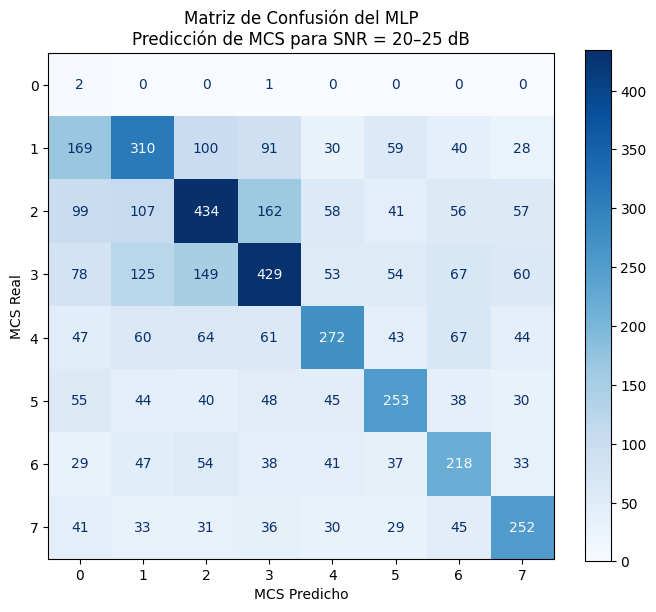

In [ ]:
# ==========================================
# CELDA 5: Matriz de Confusión del MLP
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------
# 1. Seleccionar muestras alrededor de 23 dB
# ------------------------------------------

target_snr_mask = (
    (snr_test >= 20) &
    (snr_test <= 25)
)

X_sub = X_test[target_snr_mask]
y_sub = y_test[target_snr_mask]

print("--- SUBCONJUNTO DE EVALUACIÓN ---")
print(f"Rango de SNR: 20–25 dB")
print(f"Muestras: {len(y_sub)}")

# ------------------------------------------
# 2. Obtener predicciones del MLP
# ------------------------------------------

mlp_model.eval()

with torch.no_grad():

    X_sub_tensor = torch.tensor(
        X_sub,
        dtype=torch.float32
    ).to(device)

    outputs = mlp_model(X_sub_tensor)

    preds = torch.argmax(
        outputs,
        dim=1
    ).cpu().numpy()

# ------------------------------------------
# 3. Matriz de confusión
# ------------------------------------------

cm = confusion_matrix(
    y_sub,
    preds,
    labels=np.arange(num_classes)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(num_classes)
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title(
    "Matriz de Confusión del MLP\n"
    "Predicción de MCS para SNR = 20–25 dB"
)

ax.set_xlabel("MCS Predicho")
ax.set_ylabel("MCS Real")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_mcs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()